<a href="https://colab.research.google.com/github/scottspurlock/csc4422-s2026/blob/main/labs/day19_lab_spurlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMML Day 19 Lab: Deep Learning

## First get the data from day 17 lab
wine reviews -> tf-idf scores

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import StandardScaler

import tensorflow as tf

In [20]:
# read in wine reviews
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1MmVD9CDKSf9EYjjEkCwqEJDyrf1Y_fzq')


In [21]:
def preprocess(text):
    stopwords = {"the", "is", "a", "an", "and", "this", "are", "do", "to", "of", "with", "it", "in", "on", "its", "from"}

    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = text.split()

    # remove stopwords
    tokens = [w for w in tokens if w not in stopwords]

    # stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
data = df['description']

tf_idf_model = TfidfVectorizer(tokenizer=preprocess, token_pattern=None)
tf_idf_model.fit(data)
tf_idf_matrix = tf_idf_model.transform(data)
tf_idf_array = tf_idf_matrix.toarray()

words_list = tf_idf_model.get_feature_names_out()
df_tf_idf = pd.DataFrame(tf_idf_array, columns = words_list)

print(df_tf_idf.shape)
df_tf_idf

(2000, 4665)


,1,10,100,11,1100,1100feet,12,1200,122,124,...,zest,zesti,zestier,zestl,zin,zinfandel,zing,zingi,zippi,à
0,0.0,0.0,0.150686,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.245531,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.231878,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1996,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1997,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
X = df_tf_idf

In [24]:
y = df['price']

Turn the price (numeric) into a category we can predict with a classifier. Any price below the median should be 0 and any price at or above the median should be 1.

In [25]:
med_price = df['price'].median()
mask = df['price'] > med_price
y = mask.astype(int)
y.value_counts()

,count
price,
0,1078
1,922


## Train/test split


In [26]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

# Neural nets can be sensitive to data scale
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

# define the architecture
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(4665,)), # input shape must match data columns
    tf.keras.layers.Dense(14, activation='relu'), # hidden layer 1
    tf.keras.layers.Dense(2, activation='softmax') # outputs should match number of classes
])

opt = tf.keras.optimizers.Adam(learning_rate=0.0002)

# sparse categorical crossentropy means the target labels are ordinal encoded
# and not one-hot encoded.
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# training loop
history = model.fit(Xtrain, ytrain, epochs=15, batch_size=8, validation_split=0.2)


Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4906 - loss: 1.4745 - val_accuracy: 0.4844 - val_loss: 2.0679
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5789 - loss: 0.9011 - val_accuracy: 0.4938 - val_loss: 2.5404
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6914 - loss: 0.5795 - val_accuracy: 0.5156 - val_loss: 2.6136
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7812 - loss: 0.4117 - val_accuracy: 0.5344 - val_loss: 2.5337
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8461 - loss: 0.3117 - val_accuracy: 0.5562 - val_loss: 2.4004
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9125 - loss: 0.2497 - val_accuracy: 0.5688 - val_loss: 2.2722
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9461 - loss: 0.2080 - val_accuracy: 0.5813 - val_loss: 2.1374
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9617 - loss: 0.1746 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


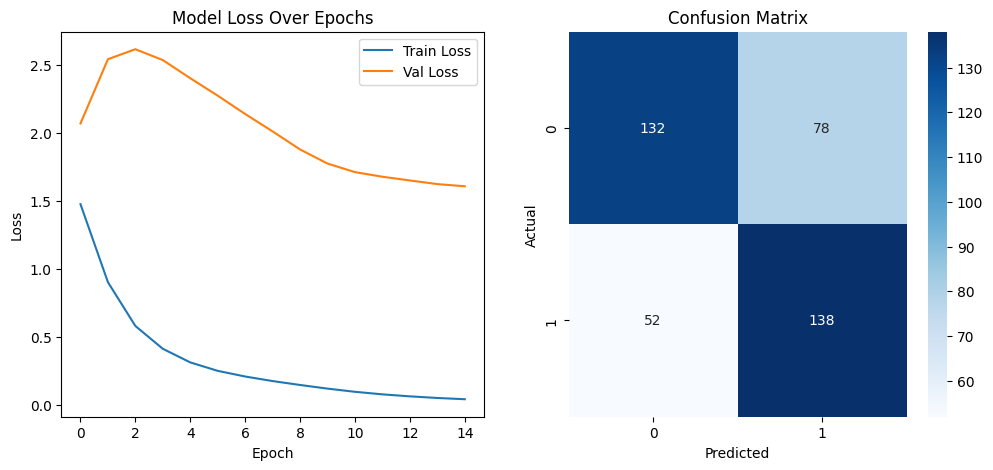

              precision    recall  f1-score   support

           0       0.72      0.63      0.67       210
           1       0.64      0.73      0.68       190

    accuracy                           0.68       400
   macro avg       0.68      0.68      0.67       400
weighted avg       0.68      0.68      0.67       400



In [27]:
# loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# confusion matrix
plt.subplot(1, 2, 2)

# note that the model has 3 outputs, which are probabilities for the classes
ypred_probs = model.predict(Xtest)

# Convert probs back to class index
ypred = np.argmax(ypred_probs, axis=1)

cm = confusion_matrix(ytest, ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate the test data
print(classification_report(ytest, ypred))